# Freight Delay Classification — Exploratory Data Analysis

Dataset: 7 CSV tables covering truck schedules, drivers, trucks, routes, traffic, and weather.
Date range: 2019-01-01 to 2019-02-12
Target: `delay` (binary 0=on-time, 1=delayed)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

# Load master modeling dataset
df = pd.read_csv('../data/processed/master_modeling.csv', parse_dates=['departure_date'])
print(f'Master dataset: {df.shape}')
print(f'Date range: {df.departure_date.min().date()} -> {df.departure_date.max().date()}')
df.head()

Master dataset: (12308, 38)
Date range: 2019-01-01 -> 2019-02-12


,truck_id,route_id,departure_date,estimated_arrival,hour,day_of_week,day_of_month,month,is_weekend,is_peak_hour,...,weather_chanceofsnow,weather_chanceofthunder,traffic_vehicles,traffic_accident,truck_age_category,truck_trip_count_hist,truck_delay_rate_hist,route_trip_count_hist,route_delay_rate_hist,delay
0,30822651,R-003c7a81,2019-01-01 07:00:00,2019-01-01 11:45:36.000000000,7,1,1,1,0,1,...,0.0,0.0,2812.0,0,mid,0,0.348879,0,0.348879,0
1,35475873,R-cd3d1fa1,2019-01-01 07:00:00,2019-01-01 16:30:36.000000000,7,1,1,1,0,1,...,0.0,0.0,2284.0,0,mid,0,0.348879,0,0.348879,0
2,11486762,R-1a63935d,2019-01-01 07:00:00,2019-01-06 05:49:12.000000000,7,1,1,1,0,1,...,0.0,0.0,2394.0,0,mid,0,0.348879,0,0.348879,0
3,88231513,R-847ea29d,2019-01-01 07:00:00,2019-01-01 12:33:36.000000000,7,1,1,1,0,1,...,0.0,0.0,2202.0,0,mid,0,0.348879,0,0.348879,0
4,93814071,R-cd48eb77,2019-01-01 07:00:00,2019-01-08 10:06:00.000000000,7,1,1,1,0,1,...,0.0,0.0,1921.0,0,mid,0,0.348879,0,0.348879,1


## 1. Target Variable: `delay`

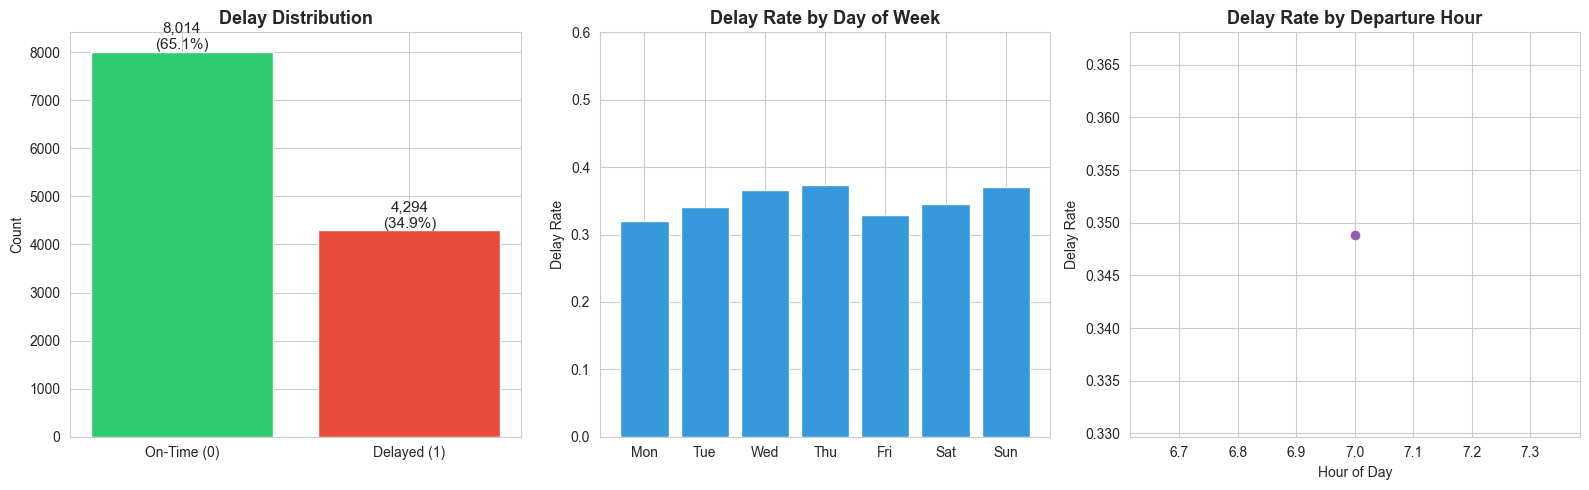

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution
vc = df['delay'].value_counts()
axes[0].bar(['On-Time (0)', 'Delayed (1)'], vc[[0,1]], color=['#2ecc71','#e74c3c'], edgecolor='white')
for i, v in enumerate(vc[[0,1]]):
    axes[0].text(i, v + 50, f'{v:,}\n({100*v/len(df):.1f}%)', ha='center', fontsize=11)
axes[0].set_title('Delay Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# By day of week
dow_delay = df.groupby('day_of_week')['delay'].mean()
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar([day_names[i] for i in dow_delay.index], dow_delay.values, color='#3498db')
axes[1].set_title('Delay Rate by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Delay Rate')
axes[1].set_ylim(0, 0.6)

# By hour
hour_delay = df.groupby('hour')['delay'].mean()
axes[2].plot(hour_delay.index, hour_delay.values, 'o-', color='#9b59b6', linewidth=2)
axes[2].set_title('Delay Rate by Departure Hour', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Delay Rate')
axes[2].set_xlabel('Hour of Day')

plt.tight_layout()
plt.savefig('../reports/figures/eda_target.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Driver Features vs Delay

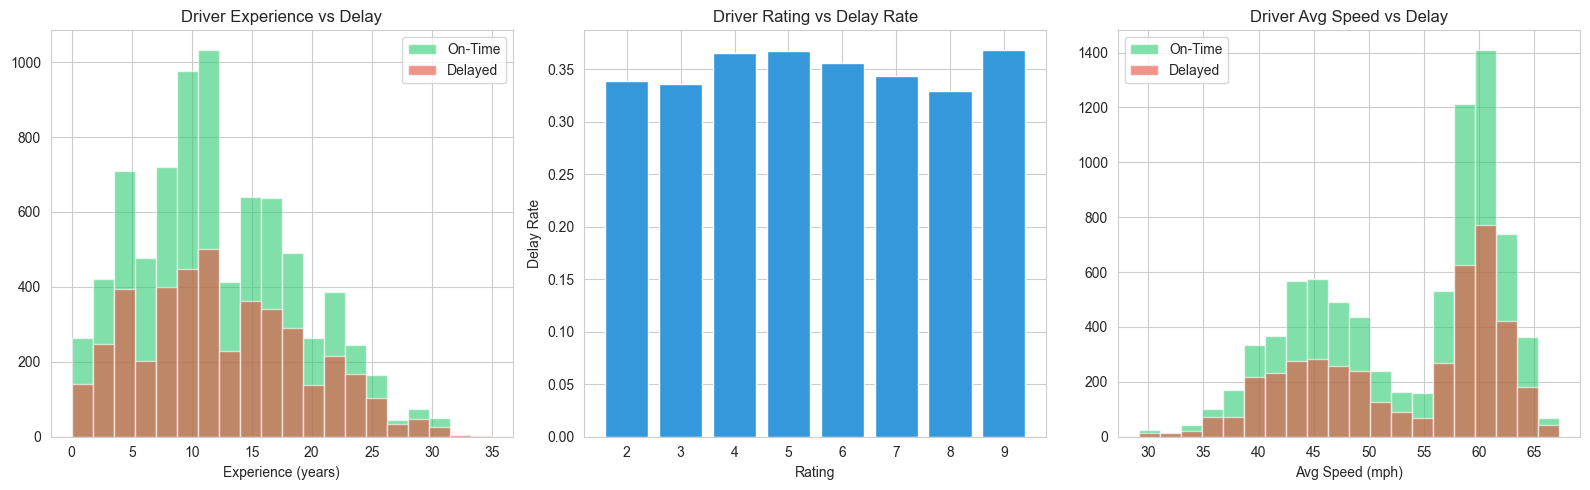

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Experience vs delay
for d_val, color, label in [(0, '#2ecc71', 'On-Time'), (1, '#e74c3c', 'Delayed')]:
    axes[0].hist(df[df['delay']==d_val]['experience'].dropna(), bins=20,
                 alpha=0.6, color=color, label=label)
axes[0].set_title('Driver Experience vs Delay', fontsize=12)
axes[0].set_xlabel('Experience (years)'); axes[0].legend()

# Ratings vs delay
rating_delay = df.groupby('driver_ratings')['delay'].mean()
axes[1].bar(rating_delay.index, rating_delay.values, color='#3498db')
axes[1].set_title('Driver Rating vs Delay Rate', fontsize=12)
axes[1].set_xlabel('Rating'); axes[1].set_ylabel('Delay Rate')

# Average speed vs delay
for d_val, color, label in [(0, '#2ecc71', 'On-Time'), (1, '#e74c3c', 'Delayed')]:
    axes[2].hist(df[df['delay']==d_val]['average_speed_mph'].dropna(), bins=20,
                 alpha=0.6, color=color, label=label)
axes[2].set_title('Driver Avg Speed vs Delay', fontsize=12)
axes[2].set_xlabel('Avg Speed (mph)'); axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/figures/eda_driver.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Truck Features vs Delay

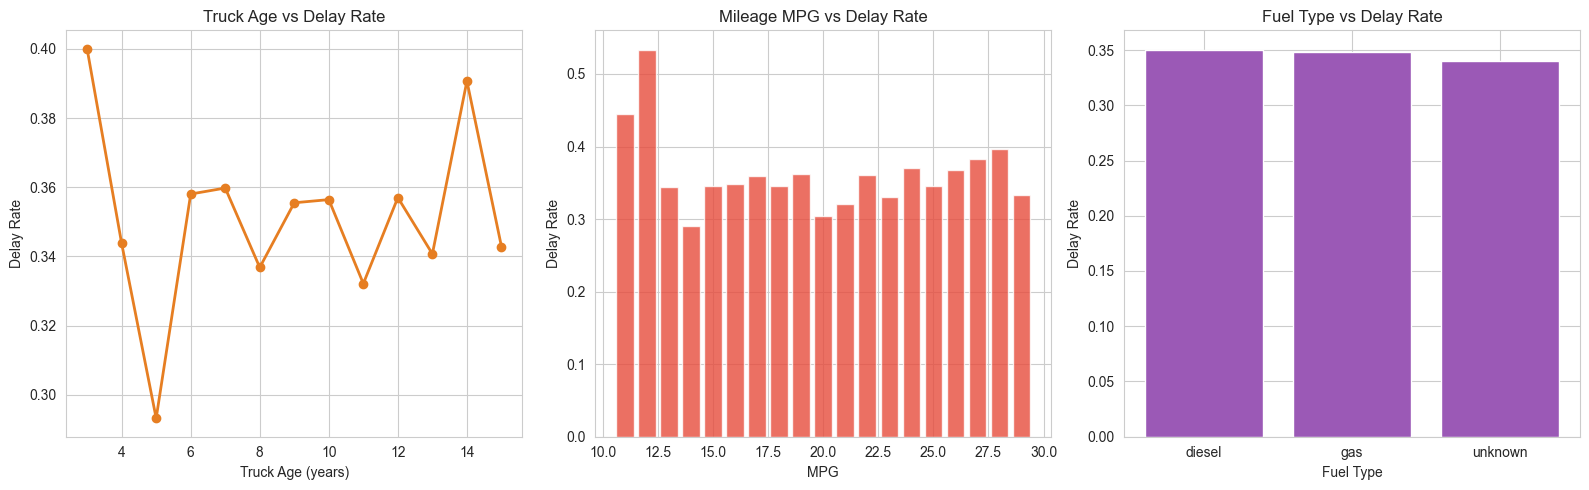

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Truck age vs delay
age_delay = df.groupby('truck_age')['delay'].mean()
axes[0].plot(age_delay.index, age_delay.values, 'o-', color='#e67e22', linewidth=2)
axes[0].set_title('Truck Age vs Delay Rate', fontsize=12)
axes[0].set_xlabel('Truck Age (years)'); axes[0].set_ylabel('Delay Rate')

# Mileage MPG vs delay
mpg_delay = df.groupby('mileage_mpg')['delay'].mean()
axes[1].bar(mpg_delay.index, mpg_delay.values, color='#e74c3c', alpha=0.8)
axes[1].set_title('Mileage MPG vs Delay Rate', fontsize=12)
axes[1].set_xlabel('MPG'); axes[1].set_ylabel('Delay Rate')

# Fuel type vs delay
fuel_delay = df.groupby('fuel_type')['delay'].mean().sort_values(ascending=False)
axes[2].bar(fuel_delay.index, fuel_delay.values, color='#9b59b6')
axes[2].set_title('Fuel Type vs Delay Rate', fontsize=12)
axes[2].set_xlabel('Fuel Type'); axes[2].set_ylabel('Delay Rate')

plt.tight_layout()
plt.savefig('../reports/figures/eda_truck.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Route Features vs Delay

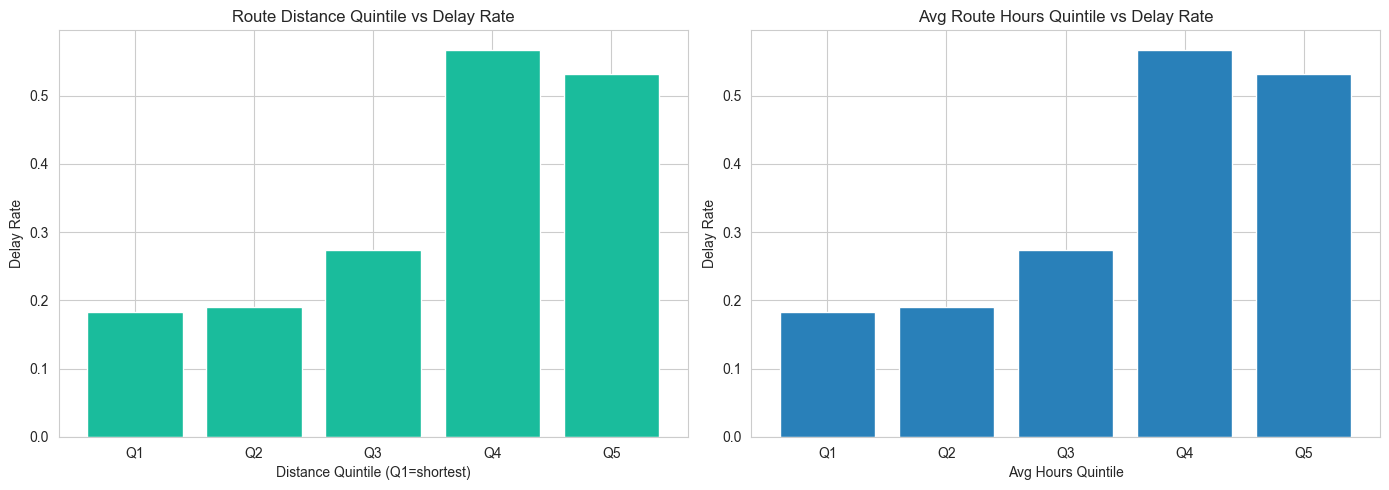

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance vs delay (binned)
df['distance_bin'] = pd.qcut(df['distance'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
dist_delay = df.groupby('distance_bin')['delay'].mean()
axes[0].bar(dist_delay.index.astype(str), dist_delay.values, color='#1abc9c')
axes[0].set_title('Route Distance Quintile vs Delay Rate', fontsize=12)
axes[0].set_xlabel('Distance Quintile (Q1=shortest)'); axes[0].set_ylabel('Delay Rate')

# Average hours vs delay
df['avg_hours_bin'] = pd.qcut(df['average_hours'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
hrs_delay = df.groupby('avg_hours_bin')['delay'].mean()
axes[1].bar(hrs_delay.index.astype(str), hrs_delay.values, color='#2980b9')
axes[1].set_title('Avg Route Hours Quintile vs Delay Rate', fontsize=12)
axes[1].set_xlabel('Avg Hours Quintile'); axes[1].set_ylabel('Delay Rate')

plt.tight_layout()
plt.savefig('../reports/figures/eda_route.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Traffic Features vs Delay

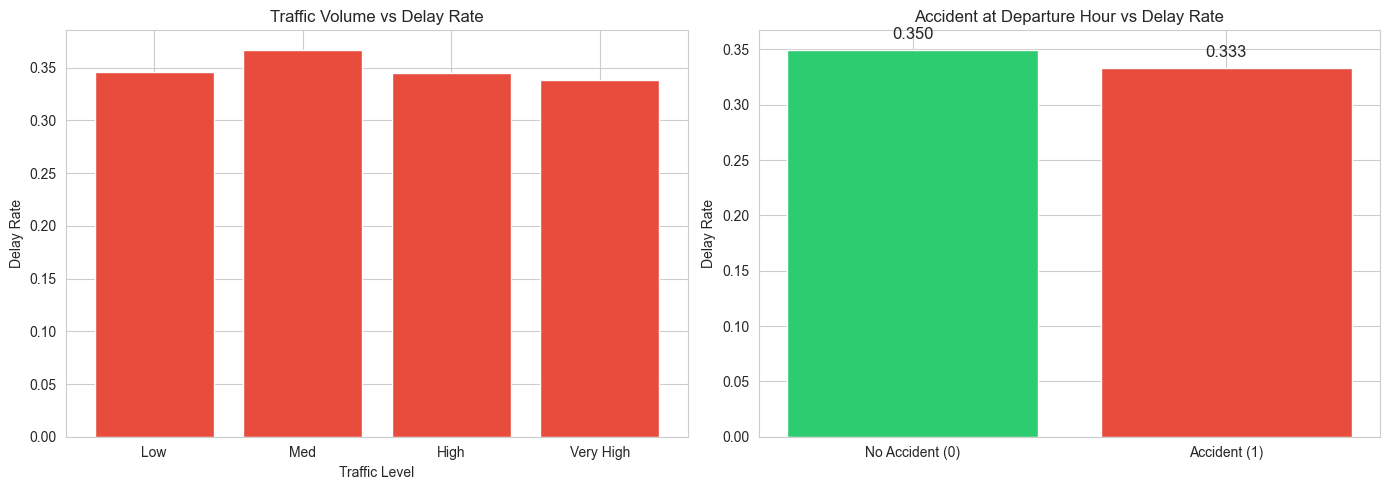

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Traffic volume vs delay
df['traffic_bin'] = pd.qcut(df['traffic_vehicles'], q=4, labels=['Low','Med','High','Very High'], duplicates='drop')
traffic_delay = df.groupby('traffic_bin')['delay'].mean()
axes[0].bar(traffic_delay.index.astype(str), traffic_delay.values, color='#e74c3c')
axes[0].set_title('Traffic Volume vs Delay Rate', fontsize=12)
axes[0].set_xlabel('Traffic Level'); axes[0].set_ylabel('Delay Rate')

# Accident vs delay
acc_delay = df.groupby('traffic_accident')['delay'].mean()
axes[1].bar(['No Accident (0)', 'Accident (1)'], acc_delay.values, color=['#2ecc71','#e74c3c'])
axes[1].set_title('Accident at Departure Hour vs Delay Rate', fontsize=12)
axes[1].set_ylabel('Delay Rate')
for i, v in enumerate(acc_delay.values):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/figures/eda_traffic.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Weather Features vs Delay

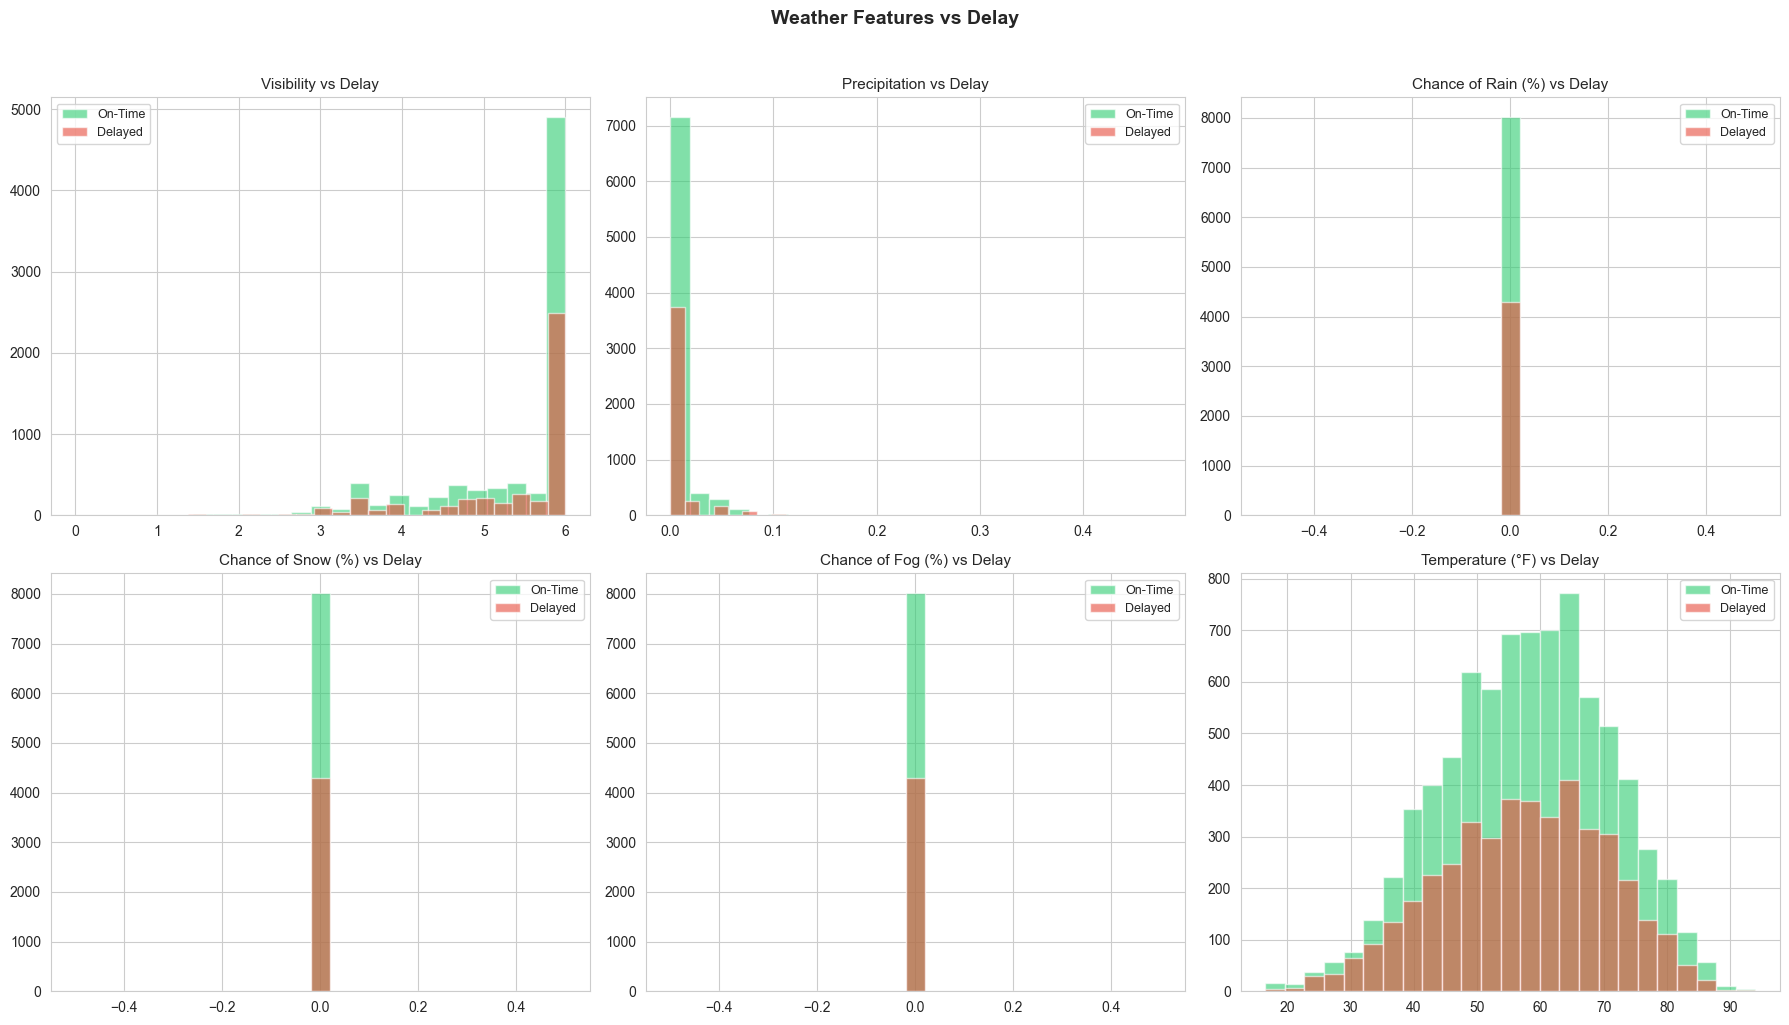

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

weather_cols = ['weather_visibility','weather_precip','weather_chanceofrain',
                'weather_chanceofsnow','weather_chanceoffog','weather_temp']
weather_labels = ['Visibility','Precipitation','Chance of Rain (%)','Chance of Snow (%)','Chance of Fog (%)','Temperature (°F)']

for i, (col, label) in enumerate(zip(weather_cols, weather_labels)):
    for d_val, color, lbl in [(0, '#2ecc71', 'On-Time'), (1, '#e74c3c', 'Delayed')]:
        axes[i].hist(df[df['delay']==d_val][col].dropna(), bins=25, alpha=0.6, color=color, label=lbl)
    axes[i].set_title(f'{label} vs Delay', fontsize=11)
    axes[i].legend(fontsize=9)

plt.suptitle('Weather Features vs Delay', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/eda_weather.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Historical Features vs Delay

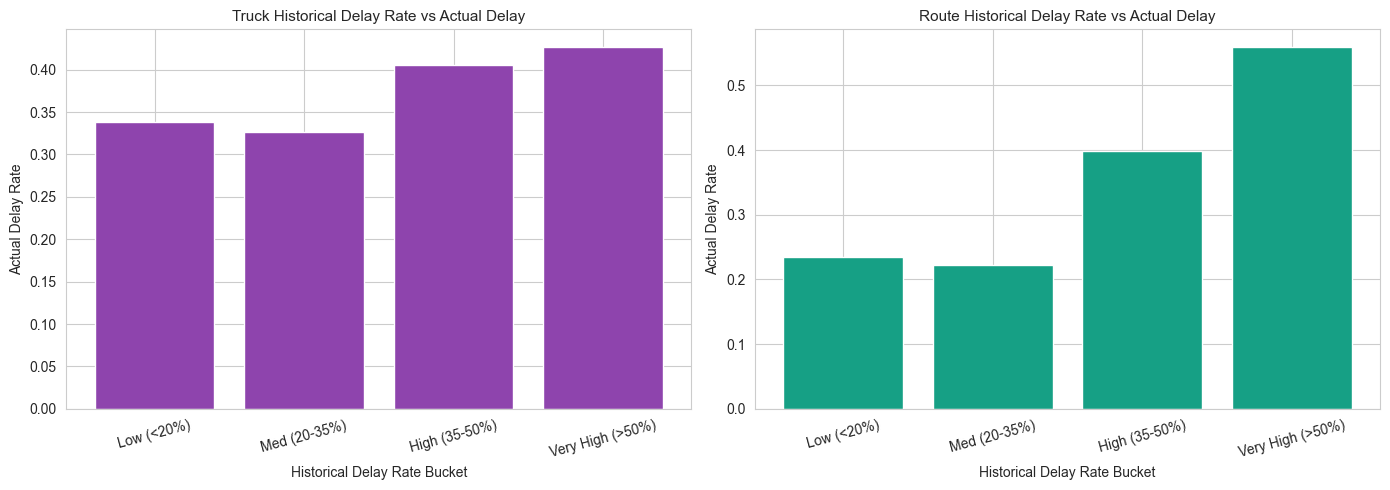

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Truck historical delay rate vs actual delay
# Bin the historical rate
df_hist = df[df['truck_trip_count_hist'] > 0].copy()
if len(df_hist) > 0:
    df_hist['truck_hist_bin'] = pd.cut(df_hist['truck_delay_rate_hist'],
                                        bins=[0,0.2,0.35,0.5,1.01],
                                        labels=['Low (<20%)','Med (20-35%)','High (35-50%)','Very High (>50%)'])
    hist_delay = df_hist.groupby('truck_hist_bin')['delay'].mean()
    axes[0].bar(hist_delay.index.astype(str), hist_delay.values, color='#8e44ad')
    axes[0].set_title('Truck Historical Delay Rate vs Actual Delay', fontsize=11)
    axes[0].set_xlabel('Historical Delay Rate Bucket'); axes[0].set_ylabel('Actual Delay Rate')
    axes[0].tick_params(axis='x', rotation=15)

# Route historical delay rate vs actual delay
df_rhist = df[df['route_trip_count_hist'] > 0].copy()
if len(df_rhist) > 0:
    df_rhist['route_hist_bin'] = pd.cut(df_rhist['route_delay_rate_hist'],
                                         bins=[0,0.2,0.35,0.5,1.01],
                                         labels=['Low (<20%)','Med (20-35%)','High (35-50%)','Very High (>50%)'])
    rhist_delay = df_rhist.groupby('route_hist_bin')['delay'].mean()
    axes[1].bar(rhist_delay.index.astype(str), rhist_delay.values, color='#16a085')
    axes[1].set_title('Route Historical Delay Rate vs Actual Delay', fontsize=11)
    axes[1].set_xlabel('Historical Delay Rate Bucket'); axes[1].set_ylabel('Actual Delay Rate')
    axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../reports/figures/eda_historical.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Feature Correlation Heatmap (Numeric)

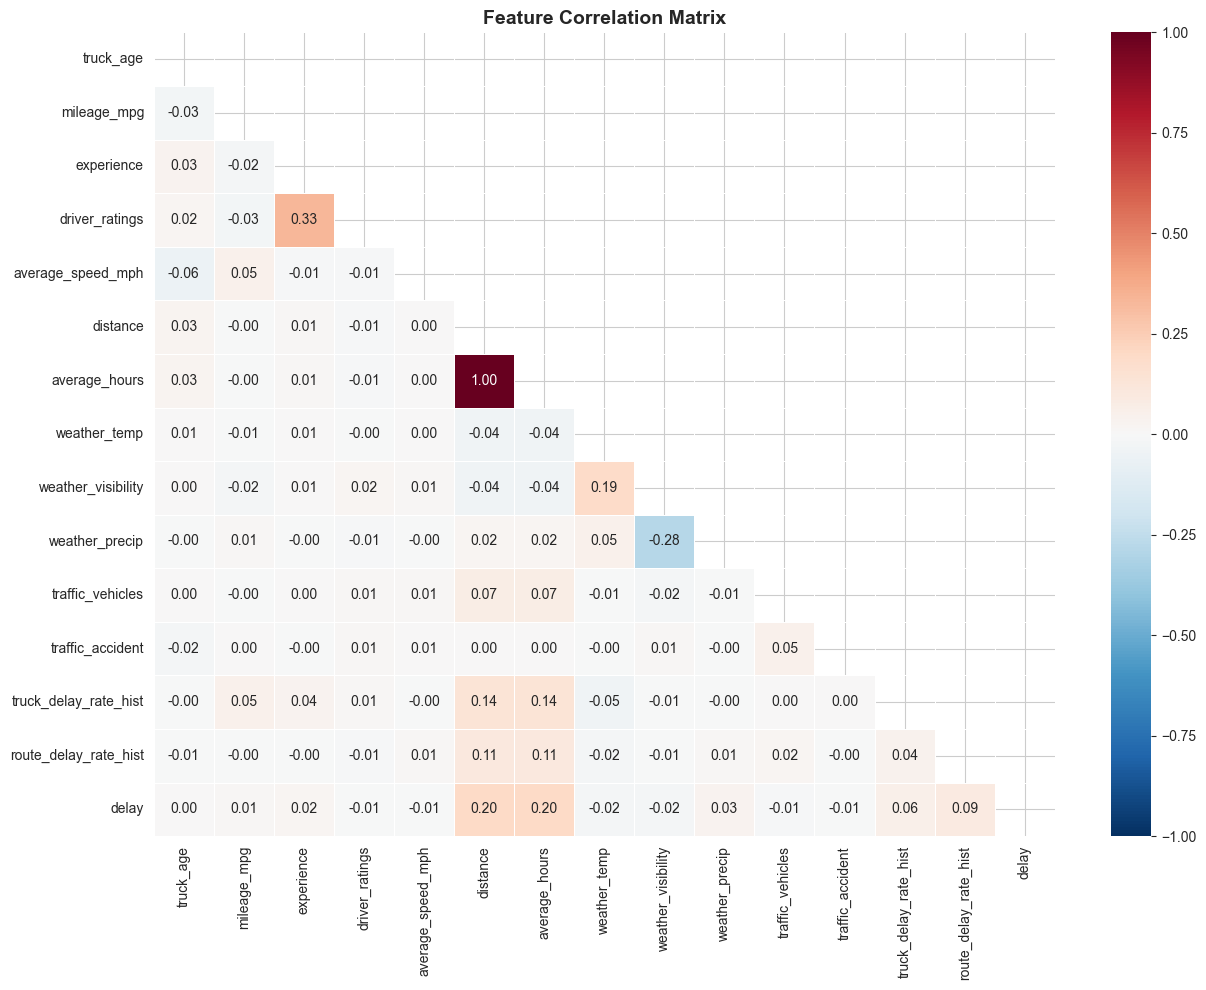


Correlation with delay (descending):
distance                 0.199900
average_hours            0.199899
route_delay_rate_hist    0.088989
truck_delay_rate_hist    0.058523
weather_precip           0.032973
experience               0.021829
weather_temp            -0.018147
weather_visibility      -0.017374
mileage_mpg              0.011230
traffic_vehicles        -0.010546
traffic_accident        -0.007521
average_speed_mph       -0.007319
driver_ratings          -0.005785
truck_age                0.000652

Note: Correlation shows association, NOT causation.


In [9]:
numeric_cols = ['truck_age','mileage_mpg','experience','driver_ratings','average_speed_mph',
                'distance','average_hours','weather_temp','weather_visibility','weather_precip',
                'traffic_vehicles','traffic_accident','truck_delay_rate_hist','route_delay_rate_hist','delay']
avail = [c for c in numeric_cols if c in df.columns]
corr = df[avail].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

# Print correlations with target
print('\nCorrelation with delay (descending):')
print(corr['delay'].drop('delay').sort_values(key=abs, ascending=False).to_string())
print('\nNote: Correlation shows association, NOT causation.')

## 9. Summary Statistics

In [10]:
print('=== DATASET SUMMARY ===')
print(f'Total rows: {len(df):,}')
print(f'On-time (delay=0): {(df.delay==0).sum():,} ({100*(df.delay==0).mean():.1f}%)')
print(f'Delayed (delay=1): {(df.delay==1).sum():,} ({100*(df.delay==1).mean():.1f}%)')
print(f'\nDate range: {df.departure_date.min().date()} to {df.departure_date.max().date()}')
print(f'Unique trucks: {df.truck_id.nunique():,}')
print(f'Unique routes: {df.route_id.nunique():,}')
print(f'\nNOTE: All EDA shows association only — correlation does NOT imply causation.')
print('See model SHAP plots for feature importance in the trained model.')

=== DATASET SUMMARY ===
Total rows: 12,308
On-time (delay=0): 8,014 (65.1%)
Delayed (delay=1): 4,294 (34.9%)

Date range: 2019-01-01 to 2019-02-12
Unique trucks: 1,249
Unique routes: 2,352

NOTE: All EDA shows association only — correlation does NOT imply causation.
See model SHAP plots for feature importance in the trained model.
